In [1]:
%reset -f 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
#Funciones auxiliares sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold #Split y cross Validation
from sklearn.metrics import cohen_kappa_score, accuracy_score, balanced_accuracy_score #Metricas
from sklearn.utils import shuffle 


#Gradient Boosting
import lightgbm as lgb


# Configuramos el estilo de las visualizaciones
sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")

 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
#Funciones auxiliares sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold #Split y cross Validation
from sklearn.metrics import cohen_kappa_score, accuracy_score, balanced_accuracy_score #Metricas
from sklearn.utils import shuffle 


#Gradient Boosting
import lightgbm as lgb


# Configuramos el estilo de las visualizaciones
sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")


SEED = 42 #Semilla de procesos aleatorios (para poder replicar exactamente al volver a correr un modelo)



In [2]:
import os
print(f"Tu Python está mirando en: {os.getcwd()}")

Tu Python está mirando en: c:\Users\GWF-SerIA\Documents\GitHub\Labo_2_Grupo_15


In [3]:


# Carga de archivos tabulares con feature enginering
df_train = pd.read_csv('work/df_train_FE_split.csv')
df_test = pd.read_csv('work/df_test_FE_split.csv')

# 1. Carga de datos
df_prob_train = pd.read_csv('work/resnet_pca_features_train.csv')
df_prob_test = pd.read_csv('work/resnet_pca_features_test.csv')

# 2. Definir las componentes a mantener (0 a 24, excluyendo la 7)
# Creamos una lista de nombres: resnet_pca_0, resnet_pca_1, ... resnet_pca_24
componentes_target = [f'resnet_pca_{i}' for i in range(25) if i != 7]

# 3. Filtrar los DataFrames
# Asegúrate de mantener 'PetID' (o tu columna de unión) para el merge posterior
columnas_finales = ['PetID'] + componentes_target

df_prob_train = df_prob_train[columnas_finales]
df_prob_test = df_prob_test[columnas_finales]

# Verificación rápida
print(f"Columnas resultantes: {df_prob_train.columns.tolist()}")
print(f"Total de componentes de imagen: {len(componentes_target)}")

Columnas resultantes: ['PetID', 'resnet_pca_0', 'resnet_pca_1', 'resnet_pca_2', 'resnet_pca_3', 'resnet_pca_4', 'resnet_pca_5', 'resnet_pca_6', 'resnet_pca_8', 'resnet_pca_9', 'resnet_pca_10', 'resnet_pca_11', 'resnet_pca_12', 'resnet_pca_13', 'resnet_pca_14', 'resnet_pca_15', 'resnet_pca_16', 'resnet_pca_17', 'resnet_pca_18', 'resnet_pca_19', 'resnet_pca_20', 'resnet_pca_21', 'resnet_pca_22', 'resnet_pca_23', 'resnet_pca_24']
Total de componentes de imagen: 24


In [4]:
# 1. Realizar el merge por PetID
# Usamos how='left' para mantener todas las filas del set tabular original
df_train_final = pd.merge(df_train, df_prob_train, on='PetID', how='left')
df_test_final = pd.merge(df_test, df_prob_test, on='PetID', how='left')

# 2. Verificar si hubo mascotas sin probabilidades (nulos)
nulos_prob = df_train_final[df_prob_train.columns.drop('PetID')].isna().sum()
if nulos_prob.any():
    print("Advertencia: Hay mascotas en train sin probabilidades de ResNet. Completando con 0 o promedio...")
    # Opción: Llenar con 0 o con una distribución uniforme (0.2 para cada clase en 5 clases)
    cols_prob = [c for c in df_prob_train.columns if c != 'PetID']
    df_train_final[cols_prob] = df_train_final[cols_prob].fillna(0)

# 3. Revisar las dimensiones finales
print(f"Dataset original: {df_train.shape}")
print(f"Dataset tras merge: {df_train_final.shape}")

# Mostrar las primeras filas para confirmar que las columnas prob_0...prob_4 estén ahí
display(df_train_final.head())

# 2. Verificar si hubo mascotas sin probabilidades (nulos)
nulos_prob = df_test_final[df_prob_test.columns.drop('PetID')].isna().sum()
if nulos_prob.any():
    print("Advertencia: Hay mascotas en test sin probabilidades de ResNet. Completando con 0 o promedio...")
    # Opción: Llenar con 0 o con una distribución uniforme (0.2 para cada clase en 5 clases)
    cols_prob = [c for c in df_prob_test.columns if c != 'PetID']
    df_test_final[cols_prob] = df_test_final[cols_prob].fillna(0)

# 3. Revisar las dimensiones finales
print(f"Dataset original: {df_test.shape}")
print(f"Dataset tras merge: {df_test_final.shape}")

# Mostrar las primeras filas para confirmar que las columnas prob_0...prob_4 estén ahí
display(df_test_final.head())


Advertencia: Hay mascotas en train sin probabilidades de ResNet. Completando con 0 o promedio...
Dataset original: (11994, 38)
Dataset tras merge: (11994, 62)


,Type,Age,Breed1,Gender,Color1,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,...,resnet_pca_15,resnet_pca_16,resnet_pca_17,resnet_pca_18,resnet_pca_19,resnet_pca_20,resnet_pca_21,resnet_pca_22,resnet_pca_23,resnet_pca_24
0,1,2,307,1,1,2,2,2,1,2,...,0.907789,0.008126,-0.589698,1.305395,-0.792262,0.126378,-2.012800,-1.290752,0.686048,-1.156728
1,1,12,307,2,2,1,1,1,1,1,...,-0.136043,-1.628431,1.275523,-2.401196,0.156608,-0.465620,1.343025,1.449378,0.162731,-0.302532
2,1,2,307,1,1,2,1,2,2,2,...,-1.432327,-1.187396,3.164775,-0.651545,-2.682748,1.150769,-0.390465,-0.365634,0.250145,-0.045817
3,1,2,307,1,3,2,2,1,1,2,...,2.140885,0.896484,0.023068,-0.071451,0.849303,-0.055667,-0.385665,-0.622450,0.354009,-0.059663
4,2,4,265,3,1,2,2,2,2,2,...,-0.548236,1.155962,1.320660,-1.145061,0.783286,-0.124565,0.046825,0.080221,-0.390760,-0.742089


Advertencia: Hay mascotas en test sin probabilidades de ResNet. Completando con 0 o promedio...
Dataset original: (2999, 38)
Dataset tras merge: (2999, 62)


,Type,Age,Breed1,Gender,Color1,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,...,resnet_pca_15,resnet_pca_16,resnet_pca_17,resnet_pca_18,resnet_pca_19,resnet_pca_20,resnet_pca_21,resnet_pca_22,resnet_pca_23,resnet_pca_24
0,1,1,307,2,1,2,2,2,2,2,...,1.416608,1.246910,-1.178541,-1.379215,-0.110131,-0.474010,0.543954,-1.050206,-0.285228,-1.211483
1,1,24,103,2,1,2,1,1,1,2,...,-0.499093,0.545347,-1.199106,-1.681302,0.761316,1.137606,0.834286,0.048654,-2.114155,-0.029736
2,1,2,307,2,2,2,1,1,1,2,...,-1.707319,-0.628417,-1.396504,1.309343,1.087662,-0.010638,1.742549,0.353996,-1.438627,0.151800
3,2,1,265,1,2,1,2,1,1,2,...,1.518542,-2.157997,0.593878,-0.053206,-0.314437,0.135445,0.538584,0.309420,-0.066882,0.349145
4,2,9,266,2,2,2,1,2,2,2,...,-0.061453,0.331656,-1.029765,0.014628,-2.422607,0.431160,-0.251440,0.302741,-1.488082,-0.291550


In [5]:
# 1. Lista de variables que DESEAMOS que sean categóricas
# (He quitado PetID, Name y RescuerID porque acordamos eliminarlas por ruido)
desired_categorical = [
    'Type', 'Breed1', 'Gender', 'Color1', 'Is_Mixed', 
    'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State', 
    'SizeCategory', 'MaturitySize', 'Description', 'Has_Name'
]

# 2. Convertir a 'category' de forma segura
for col in desired_categorical:
    # Verificamos si la columna existe en df_train_final antes de transformarla
    if col in df_train_final.columns:
        df_train_final[col] = df_train_final[col].astype('category')
        
    # Hacemos lo mismo para df_test_final
    if col in df_test_final.columns:
        df_test_final[col] = df_test_final[col].astype('category')
    else:
        # Esto te avisará si alguna columna de tu lista no está en el DataFrame
        continue 

print("✅ Conversión a categóricas finalizada sin errores.")

✅ Conversión a categóricas finalizada sin errores.


In [6]:
#Genero dataframes de train y test con sus respectivos targets
X_train = df_train_final.drop(columns=['AdoptionSpeed'])
y_train = df_train_final['AdoptionSpeed']

X_test = df_test_final.drop(columns=['AdoptionSpeed'])
y_test = df_test_final['AdoptionSpeed']

In [7]:
# 1. ELIMINAR IDENTIFICADORES
# Quitamos los IDs 
cols_to_drop = ['PetID']
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

In [8]:
import lightgbm as lgb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ============================================================================
# 1. Preparación de Datasets (Uso de validación real)
# ============================================================================
# Es fundamental que valid_sets reciba datos que el modelo NO vio en el training
dtrain = lgb.Dataset(X_train, label=y_train, free_raw_data=False)
dvalid = lgb.Dataset(X_test, label=y_test, reference=dtrain)

# ============================================================================
# 2. Parámetros y Entrenamiento
# ============================================================================
params = {
    'objective': 'multiclass',
    'num_class': 5,
    'metric': 'multi_error',
    'verbosity': -1,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 7,
    'min_data_in_leaf': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'random_state': 42
}

print("Entrenando modelo con Early Stopping...")
model = lgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    valid_sets=[dtrain, dvalid],
    valid_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=True)]
)

# ============================================================================
# 3. Importancia de Variables (Gain)
# ============================================================================
importance_type = 'gain' 

feature_importances = model.feature_importance(importance_type=importance_type)
feature_names = X_train.columns

# Crear DataFrame de importancia
df_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances,
    'importance_pct': (feature_importances / feature_importances.sum() * 100).round(2) if feature_importances.sum() > 0 else 0
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Mostrar resultados
print("\n=== Top 60 Importancia de Features (Gain) ===")
print(df_importance.head(60))


Entrenando modelo con Early Stopping...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[100]	train's multi_error: 0.268384	valid's multi_error: 0.582861

=== Top 60 Importancia de Features (Gain) ===
                   feature    importance  importance_pct
0             resnet_pca_0  18420.644649           13.80
1             resnet_pca_1   9433.724241            7.07
2   rescu_breed_experience   6269.814724            4.70
3             resnet_pca_2   5771.549097            4.32
4         rescu_avg_photos   5236.802600            3.92
5             resnet_pca_5   3493.764723            2.62
6            resnet_pca_21   3482.585418            2.61
7            resnet_pca_17   3163.326775            2.37
8             resnet_pca_6   3086.689517            2.31
9            resnet_pca_11   3070.702559            2.30
10           resnet_pca_10   3040.615792            2.28
11                     Age   2879.478154            2.16
12        

In [9]:
import pandas as pd
import numpy as np
from sklearn.metrics import average_precision_score

# ==========================================================
# 1. CÁLCULO DE GAIN (TABLA 1)
# ==========================================================
print("Calculando importancia por Gain...")
df_gain = pd.DataFrame({
    'feature': X_train.columns,
    'gain': model.feature_importance(importance_type='gain')
})

# ==========================================================
# 2. CÁLCULO DE PERMUTATION IMPACT (TABLA 2)
# ==========================================================
print("\nIniciando auditoría de impacto en Test (Permutation)...")

def get_full_audit(model, X_test_audit, y):
    # Aseguramos que el orden de columnas sea idéntico al de entrenamiento
    features = X_train.columns.tolist()
    X_test_audit = X_test_audit[features].copy() # Copia profunda para seguridad
    
    # Predicción base (asegúrate de que y sea un array plano para evitar líos de dimensiones)
    y_true = np.array(y).flatten()
    y_pred_base = model.predict(X_test_audit)
    baseline_score = average_precision_score(y_true, y_pred_base)
    
    print(f"Baseline PR-AUC en Test: {baseline_score:.4f}")
    
    results = []
    
    for i, col in enumerate(features):
        # Guardamos el estado original
        original_col = X_test_audit[col].copy()
        
        # PERMUTACIÓN SEGURA (usando .sample para mantener todo el objeto Series intacto)
        # Esto mantiene el índice, las categorías y el tipo de dato perfectamente.
        X_test_audit[col] = X_test_audit[col].sample(frac=1, replace=False).values
        
        # Si era categórica, restauramos el tipo exacto para que LightGBM no se queje
        if original_col.dtype.name == 'category':
            X_test_audit[col] = X_test_audit[col].astype('category')
            X_test_audit[col] = X_test_audit[col].cat.set_categories(original_col.cat.categories)

        # Medición de impacto
        y_pred_shuffled = model.predict(X_test_audit)
        shuffled_score = average_precision_score(y_true, y_pred_shuffled)
        drop = baseline_score - shuffled_score
        
        results.append(drop)
        
        # RESTAURACIÓN
        X_test_audit[col] = original_col
        
        if (i+1) % 5 == 0 or i == 0:
            print(f"[{i+1}/{len(features)}] Auditada: {col} | Drop: {drop:.6f}")
            
    return pd.DataFrame({'feature': features, 'test_impact': results})

# Ejecutamos la auditoría sobre una copia limpia
df_audit = get_full_audit(model, X_test.copy(), y_test)

# ==========================================================
# 3. UNIFICACIÓN Y TABLA FINAL
# ==========================================================
df_final = pd.merge(df_gain, df_audit, on='feature')

# Ordenamos por impacto real en Test (Permutation)
df_final = df_final.sort_values('test_impact', ascending=False).reset_index(drop=True)

# Agregamos % de Gain para comparar
df_final['gain_pct'] = (df_final['gain'] / df_final['gain'].sum() * 100).round(2)

print("\n" + "="*60)
print("=== MATRIZ DE DECISIÓN FINAL (GAIN vs IMPACT) ===")
print("="*60)
print(df_final[['feature', 'gain', 'test_impact', 'gain_pct']].to_string(index=False))

# Guardar
df_final.to_csv('matriz_final_maestria.csv', index=False)

Calculando importancia por Gain...

Iniciando auditoría de impacto en Test (Permutation)...
Baseline PR-AUC en Test: 0.3364
[1/60] Auditada: Type | Drop: 0.001216
[5/60] Auditada: Color1 | Drop: 0.001292
[10/60] Auditada: Sterilized | Drop: 0.004638
[15/60] Auditada: VideoAmt | Drop: 0.000086
[20/60] Auditada: Fee_x_Breed1 | Drop: 0.001192
[25/60] Auditada: rescu_avg_photos | Drop: 0.008509
[30/60] Auditada: Has_Name | Drop: 0.000126
[35/60] Auditada: Num_Colors | Drop: -0.000169
[40/60] Auditada: resnet_pca_3 | Drop: -0.001266
[45/60] Auditada: resnet_pca_9 | Drop: -0.000548
[50/60] Auditada: resnet_pca_14 | Drop: 0.000136
[55/60] Auditada: resnet_pca_19 | Drop: 0.003255
[60/60] Auditada: resnet_pca_24 | Drop: 0.000241

=== MATRIZ DE DECISIÓN FINAL (GAIN vs IMPACT) ===
               feature         gain  test_impact  gain_pct
          resnet_pca_0 18420.644649     0.048466     13.80
          resnet_pca_1  9433.724241     0.019451      7.07
rescu_breed_experience  6269.814724     0.

In [10]:
# 1. Lista de variables que DESEAMOS que sean categóricas
# (He quitado PetID, Name y RescuerID porque acordamos eliminarlas por ruido)
desired_categorical = [
    'Type', 'Breed1', 'Gender', 'Color1', 'Is_Mixed', 
    'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State', 
    'SizeCategory', 'MaturitySize', 'Description', 'Has_Name'
]

# 2. Convertir a 'category' de forma segura
for col in desired_categorical:
    # Verificamos si la columna existe en df_train_final antes de transformarla
    if col in df_train_final.columns:
        X_train[col] = X_train[col].astype('category')
        
    # Hacemos lo mismo para df_test_final
    if col in df_test_final.columns:
        X_test[col] = X_test[col].astype('category')
    else:
        # Esto te avisará si alguna columna de tu lista no está en el DataFrame
        continue 

print("✅ Conversión a categóricas finalizada sin errores.")

✅ Conversión a categóricas finalizada sin errores.


In [11]:
# 1. Ver qué columnas son de tipo 'object' (las que causan el error ValueError)
columnas_texto = X_train.select_dtypes(include=['object']).columns.tolist()

# 2. Ver si hay valores infinitos o Nulos (que a veces dan problemas)
columnas_con_nulos = X_train.columns[X_train.isnull().any()].tolist()

print(f"🚫 Columnas de texto (DEBÉS ELIMINAR O CONVERTIR): {columnas_texto}")
print(f"⚠️ Columnas con valores nulos: {columnas_con_nulos}")

# 3. Verificación rápida de tipos
print("\nConteo de tipos de datos:")
print(X_train.dtypes.value_counts())


🚫 Columnas de texto (DEBÉS ELIMINAR O CONVERTIR): []
⚠️ Columnas con valores nulos: ['Description', 'SizeCategory']

Conteo de tipos de datos:
float64     31
int64       15
category     5
category     2
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64


In [12]:
# Detecta automáticamente todas las columnas que ya son tipo 'category'
categorical_cols = X_train.select_dtypes(include=['category']).columns.tolist()

print(f"Las columnas que se pasarán como categóricas son: {categorical_cols}")

# Verificación de seguridad para nulos en categorías (opcional pero recomendado)
for col in categorical_cols:
    if X_train[col].isnull().any():
        print(f"⚠️ La columna categórica '{col}' tiene nulos. Lgbm los manejará, pero revisalo.")


Las columnas que se pasarán como categóricas son: ['Type', 'Breed1', 'Gender', 'Color1', 'MaturitySize', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State', 'Description', 'SizeCategory', 'Has_Name', 'Is_Mixed']
⚠️ La columna categórica 'Description' tiene nulos. Lgbm los manejará, pero revisalo.
⚠️ La columna categórica 'SizeCategory' tiene nulos. Lgbm los manejará, pero revisalo.


In [13]:
import optuna
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score

# Asegúrate de tener X_train, y_train y categorical_cols definidos previamente

def objective(trial):
    # 1. Definir el espacio de búsqueda de hiperparámetros
    param = {
        'objective': 'multiclass',
        'num_class': 5,
        'metric': 'multi_error',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'seed': 42,

        # Hiperparámetros a optimizar por Optuna
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.5, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 7, 50),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 10, 50),
        'min_child_samples': trial.suggest_int('min_child_samples', 100, 3000),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 40, 120, 1),
        'lambda_l1': trial.suggest_float('lambda_l1',0.001,0.5, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2',0.01,5.0, log=True),
        'min_gain_to_split':    trial.suggest_float('min_gain_to_split', 0.01, 0.2, log=True), # Peaje más caro para abrir ramas 
    }


    # 2. Configurar la Validación Cruzada
    N_SPLITS = 5
    folds = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    oof_preds = np.zeros((len(X_train), 5))

    # 3. Bucle de entrenamiento por Fold
    for fold_, (trn_idx, val_idx) in enumerate(folds.split(X_train, y_train)):
        X_tr, y_tr = X_train.iloc[trn_idx], y_train.iloc[trn_idx]
        X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
        
        trn_data = lgb.Dataset(X_tr, label=y_tr, categorical_feature=categorical_cols)
        val_data = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_cols, reference=trn_data)
        
        # Entrenar el modelo
        clf = lgb.train(
            param,
            trn_data,
            num_boost_round=500, # Un número alto, early_stopping lo detendrá antes
            valid_sets=[trn_data, val_data],
            callbacks=[
                lgb.early_stopping(stopping_rounds=30, verbose=False)
            ]
        )
        
        # Guardar predicciones de validación
        oof_preds[val_idx] = clf.predict(X_val, num_iteration=clf.best_iteration)

    # 4. Calcular la métrica final (QWK) para este Trial
    oof_predictions_classes = oof_preds.argmax(axis=1)
    kappa_score = cohen_kappa_score(y_train, oof_predictions_classes, weights='quadratic')
    
    return kappa_score

# --- EJECUCIÓN DE LA OPTIMIZACIÓN ---

print("Iniciando búsqueda de hiperparámetros con Optuna...")

# Queremos MAXIMIZAR el score Kappa
study = optuna.create_study(direction='maximize', study_name="Petfinder_LGBM_Optuna")

# Ejecutar el estudio (puedes cambiar n_trials dependiendo del tiempo que tengas)
study.optimize(objective, n_trials=150, show_progress_bar=True)

# Mostrar resultados
print("\n--- ¡Optimización Terminada! ---")
print(f"Mejor Score Kappa (OOF): {study.best_value:.4f}")
print("Mejores Hiperparámetros encontrados:")
for key, value in study.best_params.items():
    print(f"    '{key}': {value}")

c:\Users\GWF-SerIA\anaconda3\envs\ldi2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-30 12:11:15,891] A new study created in memory with name: Petfinder_LGBM_Optuna


Iniciando búsqueda de hiperparámetros con Optuna...


  0%|          | 0/150 [00:00<?, ?it/s]C:\Users\GWF-SerIA\AppData\Local\Temp\ipykernel_8020\3914610731.py:27: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresponding keyword arguments in v5.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v3.5.0 for details.
  'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 40, 120, 1),
Best trial: 0. Best value: 0.416094:   1%|          | 1/150 [00:04<11:22,  4.58s/it]C:\Users\GWF-SerIA\AppData\Local\Temp\ipykernel_8020\3914610731.py:27: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecat

[I 2026-04-30 12:11:20,456] Trial 0 finished with value: 0.41609448770433544 and parameters: {'learning_rate': 0.4482497290196738, 'num_leaves': 194, 'max_depth': 36, 'feature_fraction': 0.909465034447073, 'bagging_fraction': 0.7446573249331884, 'bagging_freq': 46, 'min_child_samples': 2903, 'min_data_in_leaf': 52, 'lambda_l1': 0.010686890208755023, 'lambda_l2': 0.08541250640616325, 'min_gain_to_split': 0.014224996287946209}. Best is trial 0 with value: 0.41609448770433544.


Best trial: 1. Best value: 0.463679:   1%|▏         | 2/150 [00:09<11:14,  4.56s/it]C:\Users\GWF-SerIA\AppData\Local\Temp\ipykernel_8020\3914610731.py:27: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresponding keyword arguments in v5.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v3.5.0 for details.
  'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 40, 120, 1),


...

[I 2026-04-30 12:23:24,777] Trial 147 finished with value: 0.46426873052166207 and parameters: {'learning_rate': 0.07498276990602207, 'num_leaves': 50, 'max_depth': 16, 'feature_fraction': 0.7938678975480303, 'bagging_fraction': 0.97674135806932, 'bagging_freq': 36, 'min_child_samples': 1485, 'min_data_in_leaf': 98, 'lambda_l1': 0.14474546978466749, 'lambda_l2': 0.01666534980562245, 'min_gain_to_split': 0.07144233721996271}. Best is trial 113 with value: 0.47447931703412993.


Best trial: 113. Best value: 0.474479:  99%|█████████▉| 149/150 [12:14<00:04,  4.59s/it]C:\Users\GWF-SerIA\AppData\Local\Temp\ipykernel_8020\3914610731.py:27: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresponding keyword arguments in v5.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v3.5.0 for details.
  'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 40, 120, 1),


[I 2026-04-30 12:23:30,015] Trial 148 finished with value: 0.4615562964764387 and parameters: {'learning_rate': 0.07092325721803866, 'num_leaves': 67, 'max_depth': 12, 'feature_fraction': 0.7822762635369233, 'bagging_fraction': 0.9553614913595428, 'bagging_freq': 34, 'min_child_samples': 1302, 'min_data_in_leaf': 92, 'lambda_l1': 0.28188074283932735, 'lambda_l2': 0.028377286196266917, 'min_gain_to_split': 0.0901235907640139}. Best is trial 113 with value: 0.47447931703412993.


Best trial: 113. Best value: 0.474479: 100%|██████████| 150/150 [12:19<00:00,  4.93s/it]

[I 2026-04-30 12:23:35,571] Trial 149 finished with value: 0.46586608052372835 and parameters: {'learning_rate': 0.0640954548797502, 'num_leaves': 136, 'max_depth': 17, 'feature_fraction': 0.8194877709721251, 'bagging_fraction': 0.9676820719346702, 'bagging_freq': 35, 'min_child_samples': 1658, 'min_data_in_leaf': 94, 'lambda_l1': 0.3429097302794285, 'lambda_l2': 0.03718256681127403, 'min_gain_to_split': 0.06616794818945237}. Best is trial 113 with value: 0.47447931703412993.

--- ¡Optimización Terminada! ---
Mejor Score Kappa (OOF): 0.4745
Mejores Hiperparámetros encontrados:
    'learning_rate': 0.06864130957907327
    'num_leaves': 62
    'max_depth': 12
    'feature_fraction': 0.7922901766375026
    'bagging_fraction': 0.973198870771007
    'bagging_freq': 35
    'min_child_samples': 1493
    'min_data_in_leaf': 87
    'lambda_l1': 0.061971822044339625
    'lambda_l2': 0.04007178519681175
    'min_gain_to_split': 0.09014044961476043


In [14]:
import lightgbm as lgb
from sklearn.metrics import cohen_kappa_score
import numpy as np

# 1. Extraer y complementar parámetros
# Asumiendo que tu objeto de optuna se llama 'study'
best_params = study.best_params 

# Añadimos los parámetros estáticos que Optuna no "entrenó"
fixed_params = {
    'objective': 'multiclass',
    'num_class': 5,
    'metric': 'multi_error',
    'verbosity': -1,
    'random_state': 42
}

# Unimos ambos diccionarios (Sintaxis de Python 3.9+)
final_params = {**fixed_params, **best_params}

# 2. Preparar los Datasets
dtrain = lgb.Dataset(X_train, label=y_train, free_raw_data=False)
dvalid = lgb.Dataset(X_test, label=y_test, reference=dtrain)

# 3. Entrenamiento Final
print(f"Entrenando con los mejores parámetros de la prueba #{study.best_trial.number}...")
final_model = lgb.train(
    final_params,
    dtrain,
    num_boost_round=1000,
    valid_sets=[dtrain, dvalid],
    valid_names=['train', 'test'],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# 4. Predicción y Cálculo de Kappa
print("\nCalculando métricas en Test...")
# model.predict devuelve probabilidades para cada clase [n_samples, n_classes]
y_prob = final_model.predict(X_test)
# Obtenemos la clase con mayor probabilidad (0, 1, 2, 3 o 4)
y_pred = np.argmax(y_prob, axis=1)

# El Kappa cuadrático ponderado (Quadratic Weighted Kappa) es el estándar en PetFinder
kappa_score = cohen_kappa_score(y_test, y_pred, weights='quadratic')

print("-" * 30)
print(f"RESULTADO FINAL KAPPA (Test): {kappa_score:.4f}")
print("-" * 30)

Entrenando con los mejores parámetros de la prueba #113...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[78]	train's multi_error: 0.138986	test's multi_error: 0.57886

Calculando métricas en Test...
------------------------------
RESULTADO FINAL KAPPA (Test): 0.3918
------------------------------


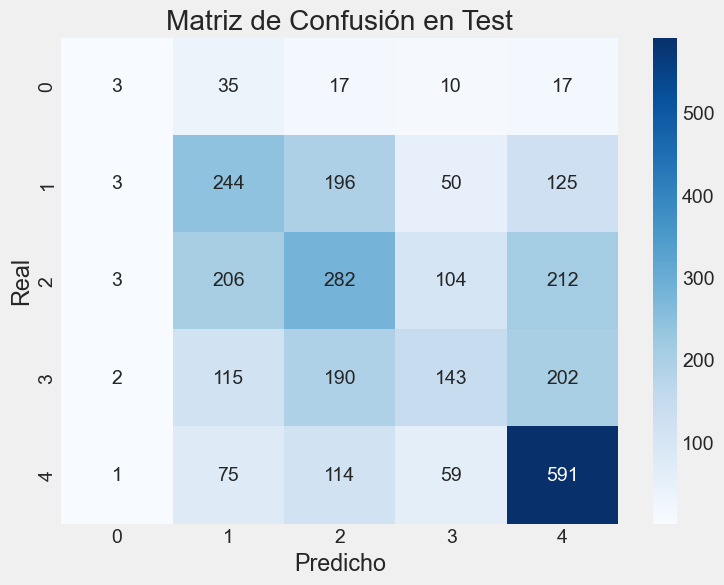

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Matriz de confusión para ver qué clases se confunden
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión en Test')
plt.show()